# Statistical Customer Segmentation System

## Notebook 01: Data Collection and Preprocessing

### Purpose

This notebook loads, validates, and prepares customer transaction data for statistical learning and customer segmentation.

### Objectives

- Load transaction records
- Assess data quality
- Examine missing values
- Identify duplicates
- Produce descriptive summaries

### Expected Outcome

A clean and validated dataset ready for exploratory analysis and feature engineering.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import os

os.makedirs("images", exist_ok=True)

In [2]:
df = pd.read_csv(
    "/content/Online Retail.csv",
    encoding="latin1"
)

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6.0,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6.0,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8.0,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6.0,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6.0,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
print("Shape:", df.shape)

print("\n")

print(df.info())

Shape: (446121, 8)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 446121 entries, 0 to 446120
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    446121 non-null  object 
 1   StockCode    446121 non-null  object 
 2   Description  444750 non-null  object 
 3   Quantity     446120 non-null  float64
 4   InvoiceDate  446120 non-null  object 
 5   UnitPrice    446120 non-null  float64
 6   CustomerID   446120 non-null  float64
 7   Country      446120 non-null  object 
dtypes: float64(3), object(5)
memory usage: 27.2+ MB
None


In [4]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,446120.000000,446120.000000,446120.000000
mean,9.756433,4.670955,15281.551396
std,166.716719,99.781619,1485.355080
min,-74215.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,14367.000000
50%,3.000000,2.080000,15287.000000
75%,11.000000,4.130000,16241.000000
max,74215.000000,38970.000000,18287.000000


## Missing Value Assessment

Understanding missing values is important because incomplete customer information can affect segmentation accuracy.

In [5]:
missing_values = (
    df.isnull()
      .sum()
      .sort_values(
          ascending=False
      )
)

missing_values

,0
Description,1371
Quantity,1
UnitPrice,1
InvoiceDate,1
CustomerID,1
Country,1
InvoiceNo,0
StockCode,0


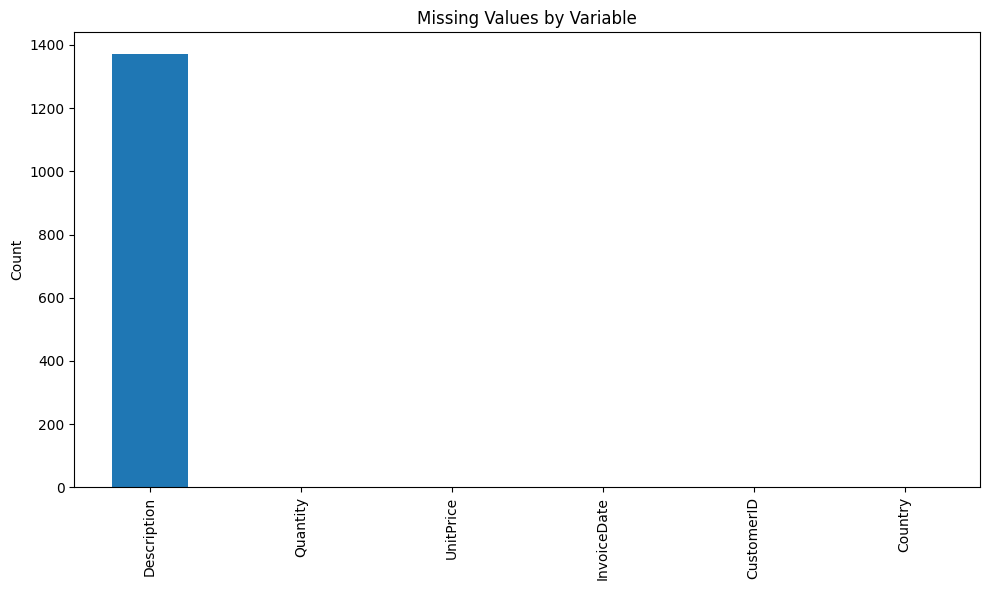

In [6]:
plt.figure(
    figsize=(10,6)
)

missing_values[
    missing_values > 0
].plot(
    kind="bar"
)

plt.title(
    "Missing Values by Variable"
)

plt.ylabel(
    "Count"
)

plt.tight_layout()

plt.savefig(
    "images/missing_values.png",
    dpi=300
)

plt.show()

## Duplicate Record Assessment

Duplicate transaction records can distort customer behavior metrics and segmentation outcomes.

In [7]:
duplicates = (
    df.duplicated()
      .sum()
)

print(
    "Duplicate Rows:",
    duplicates
)

Duplicate Rows: 3870


In [8]:
df = (
    df.drop_duplicates()
)

print(
    "Shape After Removing Duplicates:",
    df.shape
)

Shape After Removing Duplicates: (442251, 8)


## Transaction Value Creation

A transaction value variable is created to measure customer spending behavior.

In [9]:
df["Sales"] = (
    df["Quantity"]
    * df["UnitPrice"]
)

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Sales
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6.0,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6.0,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8.0,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6.0,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6.0,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [10]:
df["Sales"].describe()

,Sales
count,442250.000000
mean,18.303397
std,212.618508
min,-77183.600000
25%,3.750000
50%,9.950000
75%,17.700000
max,77183.600000


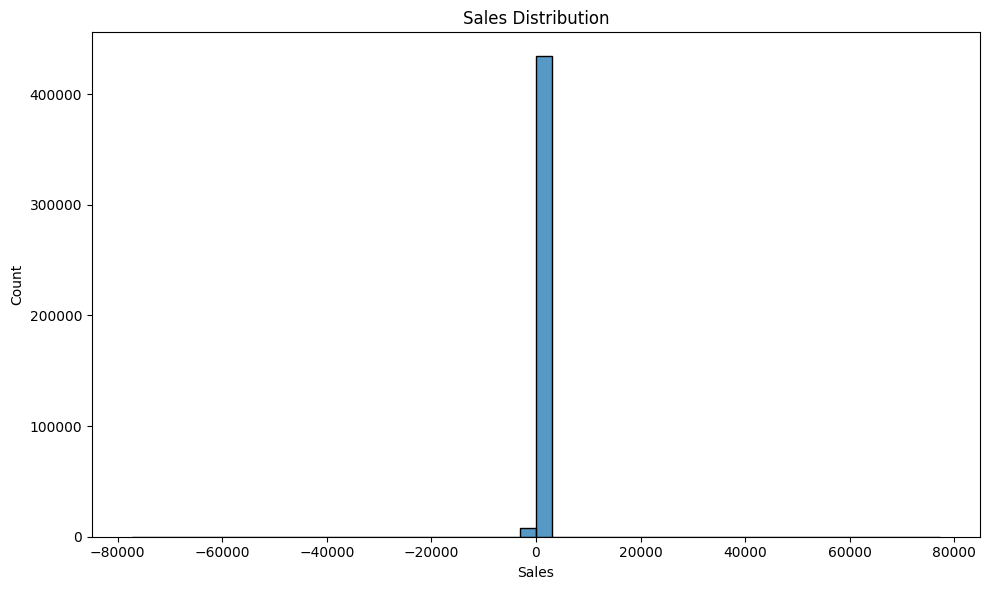

In [11]:
plt.figure(
    figsize=(10,6)
)

sns.histplot(
    df["Sales"],
    bins=50
)

plt.title(
    "Sales Distribution"
)

plt.tight_layout()

plt.savefig(
    "images/sales_distribution.png",
    dpi=300
)

plt.show()

In [12]:
df.to_csv(
    "cleaned_online_retail.csv",
    index=False
)

print(
    "Cleaned dataset saved successfully."
)

Cleaned dataset saved successfully.


## Findings

The dataset contains over half a million transaction records and provides rich information on customer purchasing behavior.

Initial assessment identified missing customer-related information and duplicate records, which were addressed during preprocessing.

A transaction-level sales variable was created to support subsequent customer-level feature engineering and segmentation analyses.